In [1]:
!pip install -q kagglehub

In [2]:
import os
import re
import string
import matplotlib.pyplot as plt
import nltk
import pandas as pd

import kagglehub
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob

nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("stopwords", quiet=True)

True

In [3]:
dataset_path = kagglehub.dataset_download("sid321axn/amazon-alexa-reviews")

100%|██████████| 164k/164k [00:00<00:00, 332kB/s]

Extracting files...


In [4]:
df = pd.read_csv(dataset_path + "/amazon_alexa.tsv", sep="\t")

In [5]:
df = df[["verified_reviews"]].dropna().reset_index(drop=True)

In [6]:
stop_words = set(stopwords.words("english"))
def process_text(text):
    text = str(text).lower()
    text = re.sub(r"\d+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))

    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words and len(word) > 1]

    return " ".join(words)

df["Clean_Review"] = df["verified_reviews"].apply(process_text)

In [7]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0.05:
        return "Positive"
    elif polarity < -0.05:
        return "Negative"
    else:
        return "Neutral"

In [8]:
df["Sentiment"] = df["Clean_Review"].apply(get_sentiment)

In [9]:
negative_reviews = df[df["Sentiment"] == "Negative"]
print("Negative Customer Complaints:")
for review in negative_reviews["verified_reviews"].head(5):
    print("-", review)

Negative Customer Complaints:
- Sometimes while playing a game, you can answer a question correctly but Alexa says you got it wrong and answers the same as you.  I like being able to turn lights on and off while away from home.
- Just what I expected....
- Does everything as expected and more.
- The outlet does not work with it. Was disappointed in that.
- Sad joke. Worthless.


In [10]:
counts = df["Sentiment"].value_counts()

In [11]:
print("\nBusiness Insights")
print("Positive Reviews :", counts.get("Positive", 0))
print("Negative Reviews :", counts.get("Negative", 0))
print("Neutral Reviews  :", counts.get("Neutral", 0))


Business Insights
Positive Reviews : 2475
Negative Reviews : 140
Neutral Reviews  : 534


In [12]:
print("\nSuggestions")
if counts.get("Negative", 0) > 0:
    print("- Improve voice recognition.")
    print("- Improve product quality and app stability.")
    print("- Improve connectivity and support response.")
else:
    print("- Customers are highly satisfied.")


Suggestions
- Improve voice recognition.
- Improve product quality and app stability.
- Improve connectivity and support response.


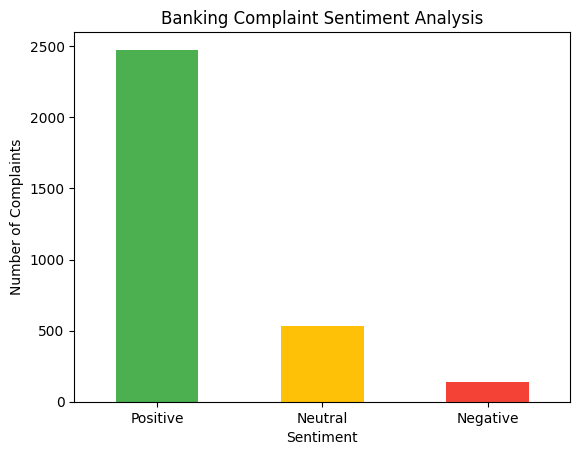

In [13]:
counts.plot(kind="bar", color=["#4CAF50", "#FFC107", "#F44336"])
plt.title("Banking Complaint Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=0)
plt.show()